# Task 3.2 — Failure Mode Analysis
**Paper:** CS4VM — Cost-Sensitive Semi-Supervised SVM

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

SEED = 42
np.random.seed(SEED); random.seed(SEED)
OUT = "."

data = load_breast_cancer()
X_all = data.data; y_all = (data.target*2-1).astype(float)
Xtr,Xte,ytr,yte = train_test_split(X_all,y_all,test_size=0.5,random_state=SEED,stratify=y_all)
sc = StandardScaler()
Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)

N_LABELED=10; N_REPEATS=30
COST_POS=5.0; COST_NEG=1.0

def total_cost(yt,yp,cp,cn):
    return cp*((yt==1)&(yp==-1)).sum()+cn*((yt==-1)&(yp==1)).sum()

class CS4VM:
    def __init__(self,C1=1.0,C2=0.1,cost_pos=5.0,cost_neg=1.0,kernel="linear",max_iter=15,random_state=42):
        self.C1=C1;self.C2=C2;self.cost_pos=cost_pos;self.cost_neg=cost_neg
        self.kernel=kernel;self.max_iter=max_iter;self.random_state=random_state
    def _elm(self,Xl,yl,Xu):
        n_u=len(Xu)
        u_p=max(1,min(int(round((yl==1).mean()*n_u)),n_u-1))
        u_m=n_u-u_p
        sv0=SVC(kernel=self.kernel,C=self.C1,class_weight={1:self.cost_pos,-1:self.cost_neg},random_state=self.random_state)
        sv0.fit(Xl,yl)
        d=np.zeros(n_u,dtype=int);d[np.argsort(-sv0.decision_function(Xu))[:u_p]]=1
        for _ in range(self.max_iter):
            pm,nm=d==1,d==0
            if pm.sum()==0 or nm.sum()==0: break
            mp,mm=Xu[pm].mean(0),Xu[nm].mean(0)
            Xa=np.vstack([Xl,mp.reshape(1,-1),mm.reshape(1,-1)])
            ya=np.concatenate([yl,[1],[-1]])
            wa=np.array([self.C1*(self.cost_pos if yi==1 else self.cost_neg) for yi in yl])
            wa=np.concatenate([wa,[self.C2*u_p*self.cost_pos],[self.C2*u_m*self.cost_neg]])
            wa/=wa.max()
            sv=SVC(kernel=self.kernel,C=1.0,random_state=self.random_state)
            sv.fit(Xa,ya,sample_weight=wa)
            dn=np.zeros(n_u,dtype=int);dn[np.argsort(-sv.decision_function(Xu))[:u_p]]=1
            if np.array_equal(d,dn): break
            d=dn
        mp=Xu[d==1].mean(0) if (d==1).sum()>0 else np.zeros(Xu.shape[1])
        mm=Xu[d==0].mean(0) if (d==0).sum()>0 else np.zeros(Xu.shape[1])
        return mp,mm,d,u_p,u_m
    def fit(self,Xl,yl,Xu):
        self.mp_,self.mm_,self.d_,self.up_,self.um_=self._elm(Xl,yl,Xu)
        Xa=np.vstack([Xl,self.mp_.reshape(1,-1),self.mm_.reshape(1,-1)])
        ya=np.concatenate([yl,[1],[-1]])
        wa=np.array([self.C1*(self.cost_pos if yi==1 else self.cost_neg) for yi in yl])
        wa=np.concatenate([wa,[self.C2*self.up_*self.cost_pos],[self.C2*self.um_*self.cost_neg]])
        wa/=wa.max()
        self.svm_=SVC(kernel=self.kernel,C=1.0,random_state=self.random_state)
        self.svm_.fit(Xa,ya,sample_weight=wa)
        return self
    def predict(self,X): return self.svm_.predict(X)

class CS4VM_U(CS4VM):
    def __init__(self,*a,uo=None,**kw): super().__init__(*a,**kw); self.uo=uo
    def _elm(self,Xl,yl,Xu):
        n_u=len(Xu)
        u_p=max(1,min(int(self.uo*n_u),n_u-1)) if self.uo else max(1,min(int(round((yl==1).mean()*n_u)),n_u-1))
        u_m=n_u-u_p
        sv0=SVC(kernel=self.kernel,C=self.C1,class_weight={1:self.cost_pos,-1:self.cost_neg},random_state=self.random_state)
        sv0.fit(Xl,yl)
        d=np.zeros(n_u,dtype=int);d[np.argsort(-sv0.decision_function(Xu))[:u_p]]=1
        for _ in range(self.max_iter):
            pm,nm=d==1,d==0
            if pm.sum()==0 or nm.sum()==0: break
            mp,mm=Xu[pm].mean(0),Xu[nm].mean(0)
            Xa=np.vstack([Xl,mp.reshape(1,-1),mm.reshape(1,-1)])
            ya=np.concatenate([yl,[1],[-1]])
            wa=np.array([self.C1*(self.cost_pos if yi==1 else self.cost_neg) for yi in yl])
            wa=np.concatenate([wa,[self.C2*u_p*self.cost_pos],[self.C2*u_m*self.cost_neg]])
            wa/=wa.max()
            sv=SVC(kernel=self.kernel,C=1.0,random_state=self.random_state)
            sv.fit(Xa,ya,sample_weight=wa)
            dn=np.zeros(n_u,dtype=int);dn[np.argsort(-sv.decision_function(Xu))[:u_p]]=1
            if np.array_equal(d,dn): break
            d=dn
        mp2=Xu[d==1].mean(0) if (d==1).sum()>0 else np.zeros(Xu.shape[1])
        mm2=Xu[d==0].mean(0) if (d==0).sum()>0 else np.zeros(Xu.shape[1])
        return mp2,mm2,d,u_p,u_m


## Failure Scenario: Misspecified Balance Parameter r (Assumption 2 Violated)

**Description:** CS4VM requires u+ (the number of unlabeled positive instances) via the balance constraint hat_y'*1 = r (Eq. 2). The paper estimates u+ from the labeled class ratio. With only 10 labeled examples, a single imbalanced draw (e.g., 8/10 positive) makes this estimate highly unreliable.

**Why the method struggles:** This violates Assumption 2 (Task 1.2): the balance constraint is hard. A wrong u+ forces the label-mean estimator (Eq. 7–8) to assign the wrong number of unlabeled instances as positive, corrupting m+ and m-, and thus invalidating the Theorem 1 guarantee.

**Demonstration:** We sweep the user-specified u+ fraction from 0.1 to 0.9 and measure total cost at each setting (true value is ~0.63).

In [2]:
true_pr=(yte==1).mean()
print(f"True positive ratio: {true_pr:.2%}")
u_fracs=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
costs_u=[]
for uf in u_fracs:
    tc=[]
    for trial in range(20):
        rng=np.random.RandomState(SEED+trial)
        idx=rng.permutation(len(Xtr))
        Xl=Xtr[idx[:N_LABELED]];yl=ytr[idx[:N_LABELED]];Xu=Xtr[idx[N_LABELED:]]
        m=CS4VM_U(cost_pos=COST_POS,cost_neg=COST_NEG,kernel="linear",random_state=SEED,uo=uf)
        m.fit(Xl,yl,Xu);tc.append(total_cost(yte,m.predict(Xte),COST_POS,COST_NEG))
    costs_u.append((np.mean(tc),np.std(tc)))
    print(f"u+ frac={uf:.1f} -> cost={costs_u[-1][0]:.1f} +/- {costs_u[-1][1]:.1f}")


True positive ratio: 62.81%
u+ frac=0.1 -> cost=196.5 +/- 53.0
u+ frac=0.2 -> cost=154.6 +/- 49.3
u+ frac=0.3 -> cost=115.8 +/- 47.5
u+ frac=0.4 -> cost=81.1 +/- 33.8


u+ frac=0.5 -> cost=53.1 +/- 20.0
u+ frac=0.6 -> cost=39.3 +/- 17.3
u+ frac=0.7 -> cost=31.6 +/- 9.4
u+ frac=0.8 -> cost=36.8 +/- 4.5
u+ frac=0.9 -> cost=53.9 +/- 6.6


**Explanation:** `CS4VM_U` overrides `_elm` to use a fixed user-specified u+ fraction rather than estimating from labeled data. Sweeping from 0.1 to 0.9 directly tests the sensitivity of the label mean plug-in (Eq. 6) to misspecified r — the core of Assumption 2.

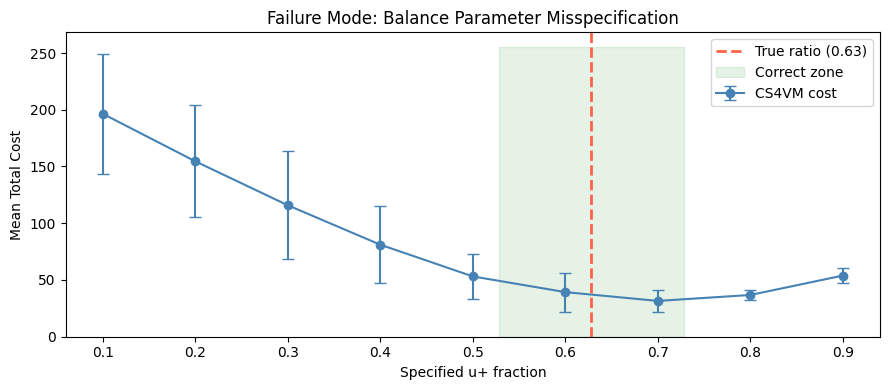

Saved failure_mode_balance_param.png


In [3]:
mn=[c[0] for c in costs_u]; sd=[c[1] for c in costs_u]
fig,ax=plt.subplots(figsize=(9,4))
ax.errorbar(u_fracs,mn,yerr=sd,fmt="o-",color="steelblue",capsize=4,label="CS4VM cost")
ax.axvline(x=true_pr,color="tomato",linestyle="--",lw=2,label=f"True ratio ({true_pr:.2f})")
ax.fill_betweenx([0,max(mn)*1.3],true_pr-0.1,true_pr+0.1,alpha=0.1,color="green",label="Correct zone")
ax.set_xlabel("Specified u+ fraction");ax.set_ylabel("Mean Total Cost")
ax.set_title("Failure Mode: Balance Parameter Misspecification")
ax.legend();ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(f"{OUT}/results/failure_mode_balance_param.png",dpi=120,bbox_inches="tight")
plt.show();print("Saved failure_mode_balance_param.png")


## Why CS4VM Fails Here

The U-shaped cost curve confirms the failure: cost is minimised near the true u+ ratio (~0.63) and rises sharply at both extremes. Two failure pathways operate:

**1. Corrupted label means:** If u+=90% but true rate is 63%, m+ is computed from a mixed set that includes ~30% true negatives. The plug-in objective (Eq. 6) receives a biased positive mean, shifting the boundary toward the negative side and increasing expensive false negatives.

**2. Wrong margin weights:** In Eq. (7)–(8), constraints use c(+1)*rho weighted by u+ and c(-1)*rho weighted by u-. A wrong u+ changes these relative weights, degrading the quality of the assignment d and hence the label means.

This connects directly to Task 1.2 Assumption 2: "if r is wrong, the estimated label means will be biased." With only 10 labeled examples, the labeled class ratio is an unreliable proxy for the true unlabeled ratio, making this failure practically common.

**Suggested modification (no implementation required):** Replace the hard constraint d'*1 = u+ in Eq. (2) with a soft regularisation penalty lambda * |sum_i d_i/n_u - r_hat|^2, where r_hat is updated via an EM-style prior estimate on the unlabeled data. This would make the algorithm robust to small mislabelings in the labeled set without requiring an exact r.